# Cuaderno de clase
## Solución al problema de los N-cuerpos: método de Euler y Leap-frog

In [1]:
!pip install -Uq pymcel rebound pandas plotly nbformat 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.6/830.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 88.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 110.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 101.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 65.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you h

In [ ]:
import pymcel as pc
import numpy as np

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


Obtiene la posición del Sol para el día de hoy:

In [6]:
tabla, jd, X_sol = pc.consulta_horizons(
    id='Sun',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)
X_sol

array([-3.99267884e+08, -8.24090450e+08,  1.85429947e+07,  1.22108229e+01,
        1.23932702e+00, -2.42604119e-01])

In [7]:
# Obtener la posición de Júpiter usando el mismo patrón que para el Sol
tabla_jup, jd_jup, X_jup = pc.consulta_horizons(
    id='Jupiter Barycenter',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)

X_jup

array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09, -1.21253772e+04,
       -4.61863891e+03,  2.90510926e+02])

Extraigamos posiciones y velocidades directamente del vector de estado:

In [9]:
r_sol_0 = X_sol[:3]
v_sol_0 = X_sol[3:]

r_jup_0 = X_jup[:3]
v_jup_0 = X_jup[3:]

Apliquemos el método de Euler:

In [10]:
deltat = 1 * 86400 # un día en segundos
r_jup_dt = r_jup_0 + v_jup_0 * deltat
r_sol_dt = r_sol_0 + v_sol_0 * deltat

r_jup_0, r_jup_dt

(array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09]),
 array([-3.14547192e+11,  7.16132604e+11,  4.06889651e+09]))

In [11]:
mu_sol = pc.constantes.mu_sun
mu_jup = pc.constantes.mu_jupiter
rij_vec = r_jup_0 - r_sol_0
v_jup_dt = v_jup_0 - mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_jup_dt

array([-12117.89040582,  -4635.79206931,    290.41467508])

In [12]:
# Calculamos la velocidad del Sol en t + deltat usando la misma aproximación
# (aceleración debida a la gravedad de Júpiter)

rij_vec_sol = r_sol_0 - r_jup_0          # vector desde Júpiter hasta el Sol
v_sol_dt = v_sol_0 - mu_jup * rij_vec_sol / np.linalg.norm(rij_vec_sol)**3 * deltat

v_sol_dt

array([12.2036746 ,  1.25570472, -0.24251222])

Calculemos las posiciones en días sucesivos por 12 años y grafiquemos:

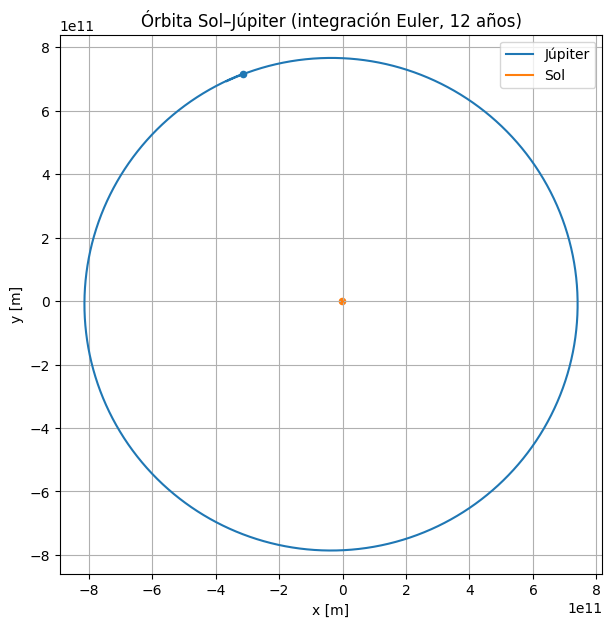

In [13]:
import matplotlib.pyplot as plt

# Tiempo total: 12 años en segundos (aprox.)
years = 12
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year

# Paso de integración: ya tenemos deltat = 1 día en segundos
N_steps = int(T_total // deltat)

# Inicializamos posiciones y velocidades con los valores actuales
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()

r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Listas para guardar la trayectoria
r_jup_hist = []
r_sol_hist = []

for _ in range(N_steps):
    # Guardamos posiciones actuales
    r_jup_hist.append(r_jup.copy())
    r_sol_hist.append(r_sol.copy())

    # Vector de separación Júpiter - Sol
    rij = r_jup - r_sol
    r = np.linalg.norm(rij)

    # Aceleraciones mutuas (dos cuerpos)
    a_jup = -mu_sol * rij / r**3
    a_sol =  mu_jup * rij / r**3  # misma dirección, signo contrario y masa diferente

    # Integración tipo Euler (mismo esquema que usaste antes)
    v_jup = v_jup + a_jup * deltat
    r_jup = r_jup + v_jup * deltat

    v_sol = v_sol + a_sol * deltat
    r_sol = r_sol + v_sol * deltat

r_jup_hist = np.array(r_jup_hist)
r_sol_hist = np.array(r_sol_hist)

# Gráfica de órbita en el plano XY
plt.figure(figsize=(7, 7))
plt.plot(r_jup_hist[:, 0], r_jup_hist[:, 1], label="Júpiter", color="tab:blue")
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")

# Marcamos posiciones iniciales
plt.scatter(r_jup_0[0], r_jup_0[1], color="tab:blue", s=20, marker="o")
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=20, marker="o")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbita Sol–Júpiter (integración Euler, 12 años)")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

Veamos cómo evoluciona la energía total del sistema:

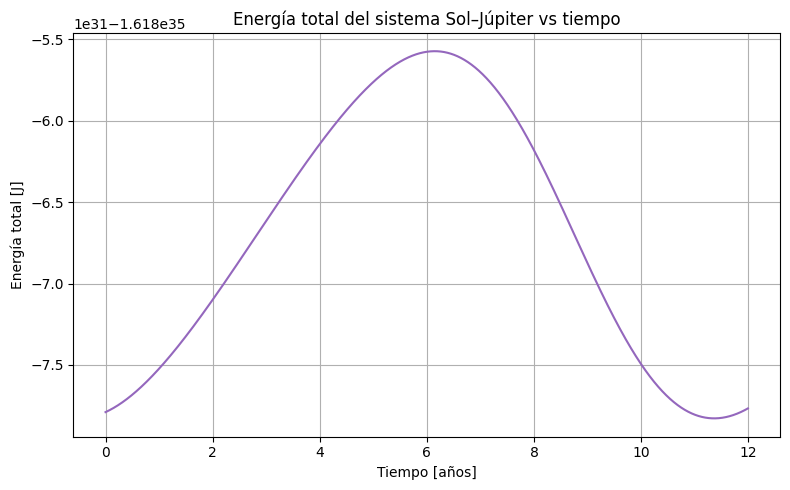

In [14]:
# Cálculo y gráfico de la energía total (cinética + potencial) en función del tiempo

# Masas a partir de parámetros gravitacionales (mu = G*M)
G = 6.67430e-11  # m^3 kg^-1 s^-2
M_sol = mu_sol / G
M_jup = mu_jup / G

# Tiempo asociado a cada paso (en segundos y en años)
t_array = np.arange(N_steps) * deltat          # s
t_years = t_array / seconds_per_year          # años

# Posición relativa Júpiter–Sol en cada instante
r_rel = r_jup_hist - r_sol_hist               # vector r_jup - r_sol
r_norm = np.linalg.norm(r_rel, axis=1)        # distancia |r|

# Energía potencial gravitatoria (dos cuerpos)
U = -G * M_sol * M_jup / r_norm               # J

# Velocidades relativas aproximadas por diferencias finitas hacia adelante
v_jup_hist = np.diff(r_jup_hist, axis=0) / deltat
v_sol_hist = np.diff(r_sol_hist, axis=0) / deltat

# Igualamos longitud de arrays de energía recortando el último paso en U
U = U[:-1]
t_years_energy = t_years[:-1]

# Energías cinéticas
K_jup = 0.5 * M_jup * np.sum(v_jup_hist**2, axis=1)
K_sol = 0.5 * M_sol * np.sum(v_sol_hist**2, axis=1)

E_total = K_jup + K_sol + U    # energía total

plt.figure(figsize=(8, 5))
plt.plot(t_years_energy, E_total, color="tab:purple")
plt.xlabel("Tiempo [años]")
plt.ylabel("Energía total [J]")
plt.title("Energía total del sistema Sol–Júpiter vs tiempo")
plt.grid(True)
plt.tight_layout()
plt.show()

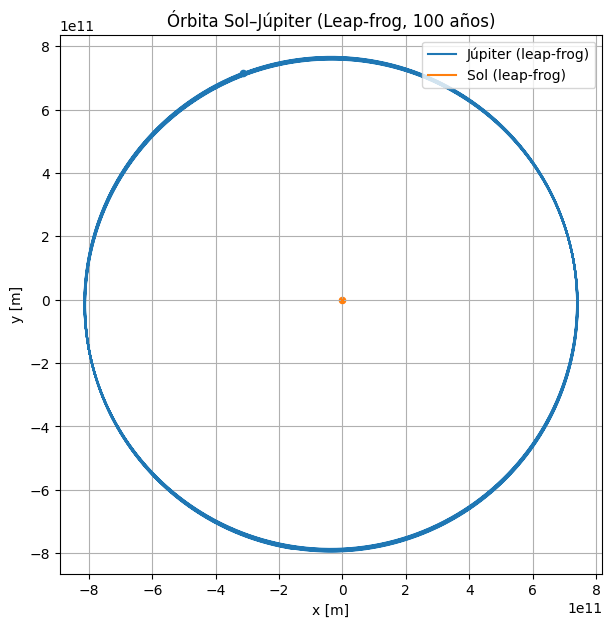

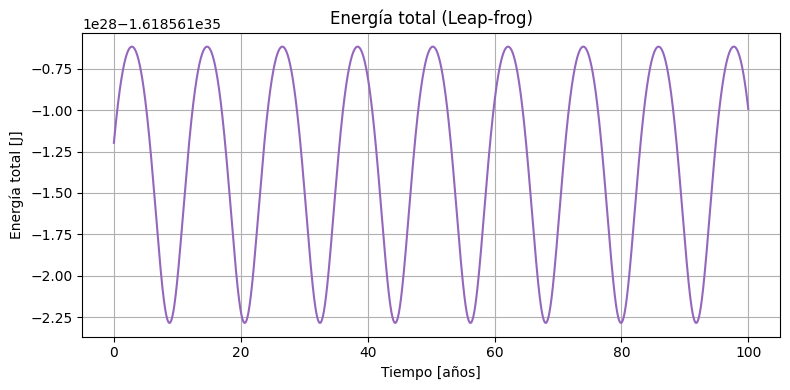

In [16]:
# Clase Taller Leap-frog para 100 años
years = 100
T_total = years * seconds_per_year
N_steps = int(T_total // deltat)

# condiciones iniciales (usar variables ya definidas en el notebook)
rj = r_jup_0.copy()
rs = r_sol_0.copy()
vj = v_jup_0.copy()
vs = v_sol_0.copy()

# aceleraciones iniciales
rij = rj - rs
rmag = np.linalg.norm(rij)
a_j = -mu_sol * rij / rmag**3
a_s = -mu_jup * (rs - rj) / rmag**3

# velocidades en semi-paso
vj_half = vj + 0.5 * a_j * deltat
vs_half = vs + 0.5 * a_s * deltat

# listas para almacenar
rj_hist = [rj.copy()]
rs_hist = [rs.copy()]
vj_hist = [vj.copy()]
vs_hist = [vs.copy()]

for _ in range(N_steps):
    # drift
    rj = rj + vj_half * deltat
    rs = rs + vs_half * deltat

    # nueva aceleración
    rij = rj - rs
    rmag = np.linalg.norm(rij)
    a_j = -mu_sol * rij / rmag**3
    a_s = -mu_jup * (rs - rj) / rmag**3

    # kick
    vj_half = vj_half + a_j * deltat
    vs_half = vs_half + a_s * deltat

    # velocidad en tiempo entero correspondiente a las posiciones guardadas
    vj_full = vj_half - 0.5 * a_j * deltat
    vs_full = vs_half - 0.5 * a_s * deltat

    # almacenar
    rj_hist.append(rj.copy())
    rs_hist.append(rs.copy())
    vj_hist.append(vj_full.copy())
    vs_hist.append(vs_full.copy())

# convertir a arrays
rj_hist = np.array(rj_hist)
rs_hist = np.array(rs_hist)
vj_hist = np.array(vj_hist)
vs_hist = np.array(vs_hist)

# Gráfica de órbita XY
plt.figure(figsize=(7,7))
plt.plot(rj_hist[:,0], rj_hist[:,1], label="Júpiter (leap-frog)", color="tab:blue")
plt.plot(rs_hist[:,0], rs_hist[:,1], label="Sol (leap-frog)", color="tab:orange")
plt.scatter(r_jup_0[0], r_jup_0[1], color="tab:blue", s=20)
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=20)
plt.axis("equal")
plt.legend()
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.title(f"Órbita Sol–Júpiter (Leap-frog, {years} años)")
plt.grid(True)
plt.show()

# Energía total vs tiempo
r_rel = rj_hist - rs_hist
r_norm = np.linalg.norm(r_rel, axis=1)
U_lf = -G * M_sol * M_jup / r_norm
K_jup_lf = 0.5 * M_jup * np.sum(vj_hist**2, axis=1)
K_sol_lf = 0.5 * M_sol * np.sum(vs_hist**2, axis=1)
E_total_lf = K_jup_lf + K_sol_lf + U_lf

t_years_lf = np.arange(len(E_total_lf)) * deltat / seconds_per_year
plt.figure(figsize=(8,4))
plt.plot(t_years_lf, E_total_lf, color="tab:purple")
plt.xlabel("Tiempo [años]"); plt.ylabel("Energía total [J]")
plt.title("Energía total (Leap-frog)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numba
from numba import njit
#